<a href="https://colab.research.google.com/github/FranciscoDegiovani/python-eda-retail/blob/main/notebooks/eda_online_retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install openpyxl

In [8]:
## 1. Loading the data
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('Online_Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
## 2. First look at the data

Checking structure, data types, and missing values before doing anything else.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
## 2. First look at the data
##Checking structure, data types, and missing values before doing anything else.
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [11]:
## 3. Separating sales from returns and adjustments
#Quantity and UnitPrice had negative values. Instead of dropping them, I'm splitting the data into sale / return / adjustment so returns can be analyzed on their own later.

df['TransactionType'] = 'Sale'
df.loc[df['Quantity'] < 0, 'TransactionType'] = 'Return'
df.loc[df['UnitPrice'] < 0, 'TransactionType'] = 'Adjustment'

df['TransactionType'].value_counts()

,count
TransactionType,
Sale,531283
Return,10624
Adjustment,2


In [12]:
## 4. Total revenue

df['Revenue'] = df['Quantity'] * df['UnitPrice']

sales = df[df['TransactionType'] == 'Sale']

print(f"Total revenue (sales only): £{sales['Revenue'].sum():,.2f}")

Total revenue (sales only): £10,666,684.54


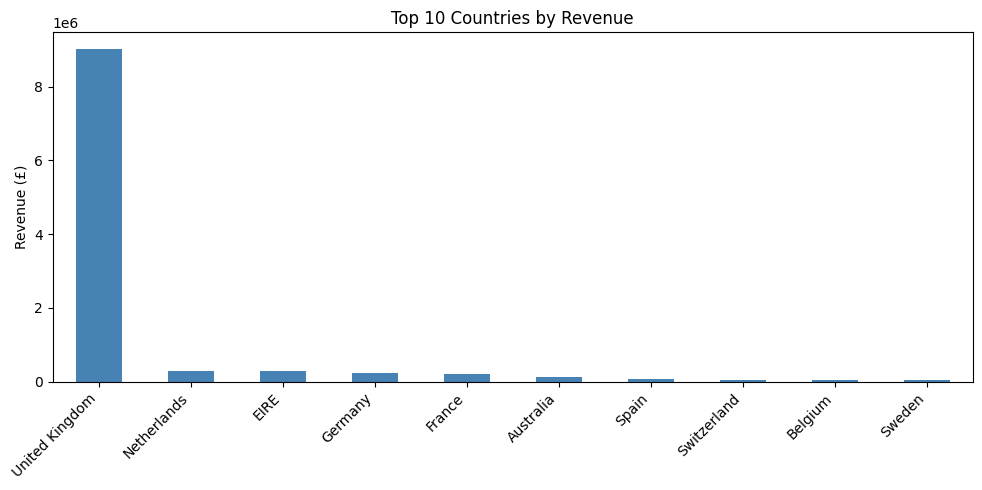

In [13]:
## 5. Revenue by country

country_revenue = sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
country_revenue.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue (£)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

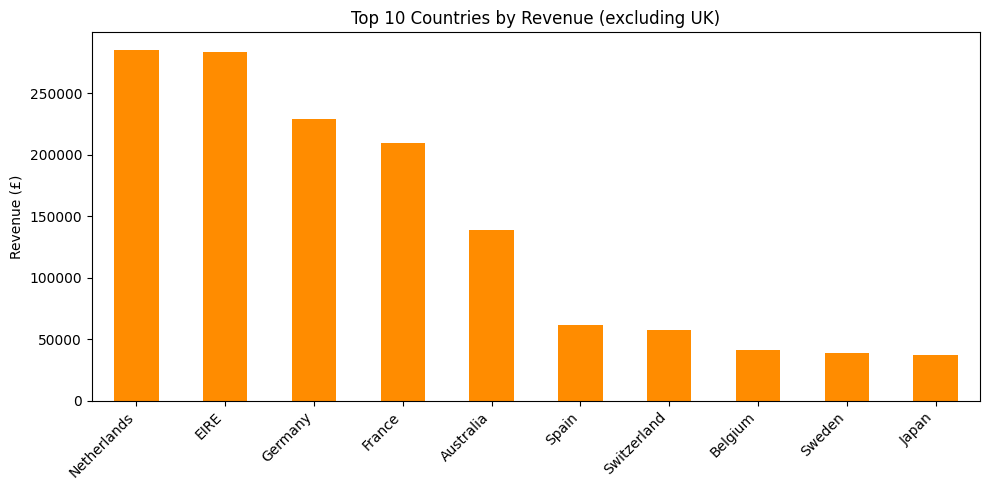

In [14]:
#UK domina meio que sozinho aqui, o que faz sentido, é um dataset de um varejista britânico.
# Vale olhar sem o UK também, pra ver os outros mercados em escala melhor
country_revenue_no_uk = sales[sales['Country'] != 'United Kingdom'].groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
country_revenue_no_uk.plot(kind='bar', color='darkorange')
plt.title('Top 10 Countries by Revenue (excluding UK)')
plt.ylabel('Revenue (£)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

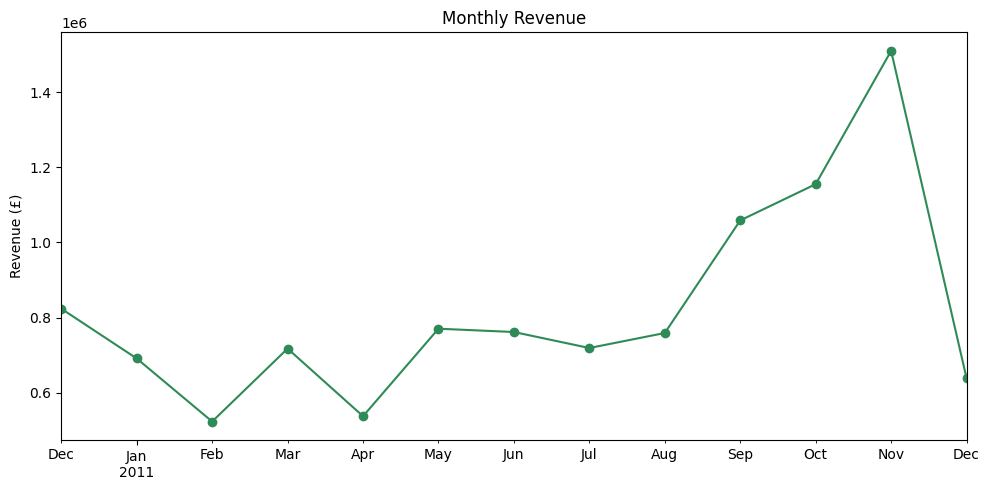

In [16]:
## 6. Revenue over time

sales_by_month = sales.set_index('InvoiceDate').resample('ME')['Revenue'].sum()

plt.figure(figsize=(10, 5))
sales_by_month.plot(kind='line', marker='o', color='seagreen')
plt.title('Monthly Revenue')
plt.ylabel('Revenue (£)')
plt.xlabel('')
plt.tight_layout()
plt.show()

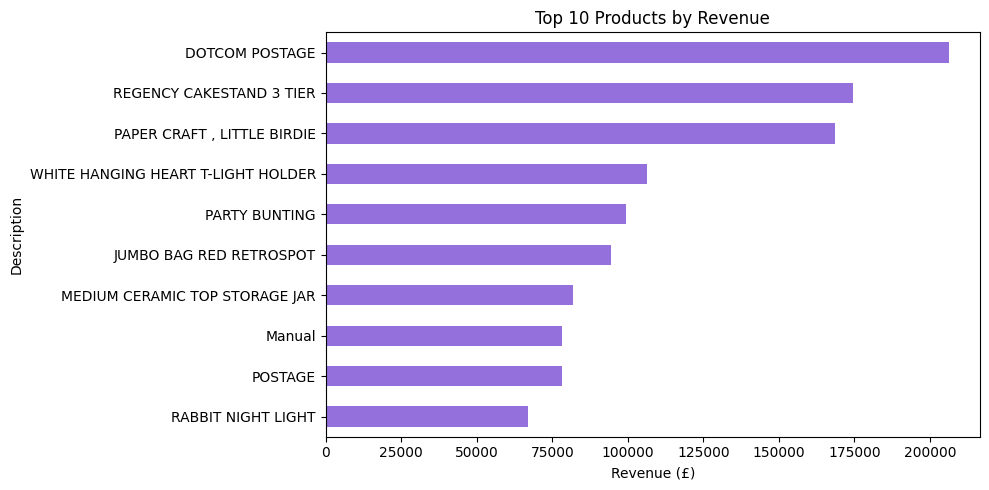

In [17]:
## 7. Best-selling products

top_products = sales.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_products.plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
## 8. Returns — quick look
#Voltando nas devoluções que separamos antes, só pra entender se tem algum padrão.

returns = df[df['TransactionType'] == 'Return']
top_returned = returns.groupby('Description')['Quantity'].sum().sort_values().head(10)

print(f"Total returned units: {abs(returns['Quantity'].sum()):,}")
top_returned

Total returned units: 484,531


,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",-80995
MEDIUM CERAMIC TOP STORAGE JAR,-74494
printing smudges/thrown away,-19200
"Unsaleable, destroyed.",-15644
check,-13247
?,-9496
ROTATING SILVER ANGELS T-LIGHT HLDR,-9376
Printing smudges/thrown away,-9058
Damaged,-7540


## 9. Conclusion

A few takeaways:
- The UK dominates revenue by a wide margin — makes sense for a UK-based retailer. Excluding it, Netherlands, EIRE, and Germany lead the international markets.
- Revenue peaks sharply in November, likely holiday season stocking, then drops in December (probably because the dataset cuts off mid-December).
- "PAPER CRAFT, LITTLE BIRDIE" shows up both as a top revenue product and as the single largest return (-80,995 units) — same magnitude as the negative Quantity outlier seen in the initial describe(). This looks like one abnormal transaction rather than a real return pattern, and would be worth validating with the source system before trusting it in a business report.